## TASK 3 — Simple Linear Regression

In [1]:
# import libraries
import pandas as pd, yfinance as yf

# select assets and benchmark
TICKER = ["NVDA", "AMD", "INTC"]
BENCH  = ["QQQ"] 
TICKER = TICKER + BENCH

# 3 year period
end = pd.Timestamp.today().normalize()
start = end - pd.DateOffset(months=36)

# download adjusted close prices
df = yf.download(TICKER, start=start, end=end, interval="1d", auto_adjust=True)[["Close"]]

# flatten column names if multi-index
# i am not sure why the template appends an extra index on the columns
df.columns = [col if isinstance(col, str) else col[1] for col in df.columns]

# reset index to make Date a column
df = df.reset_index()

# sort values by date
df = df.sort_values("Date")

# forward fill and drop any NAs
df = df.ffill().dropna()

# compute returns
df_returns = df[TICKER].pct_change().rename(columns=lambda x: x+ "_Return")

# align return columns to match df
price_cols = df.columns[1:]
df_returns = df_returns[[col + "_Return" for col in price_cols]]

# concatting two datas
df = pd.concat([df, df_returns], axis=1)

# fill returns of the first row to 0
df.fillna(0, inplace=True)

# convert necessary variables to numeric
# consumes a lot of time despite values being numeric already
variables = TICKER + [t + "_Return" for t in TICKER]
for v in variables:
    df[v] = pd.to_numeric(df[v], errors='coerce')

# save files
df.to_csv("prices_clean.csv", index=False)

# ==============================
# TRANSFORMING QUANTITATIVE DATA
# ==============================

# compress wide-format returns into long format
long_df = df.melt(id_vars="Date", value_vars=[t + "_Return" for t in TICKER], var_name="Ticker", value_name="Return")

# clean ticker names
long_df["Ticker"] = long_df["Ticker"].str.replace("_Return", "")

# convert ticker to categorical variables
long_df["Ticker"] = long_df["Ticker"].astype("category")

# save files
long_df.to_csv("returns_long_format.csv", index=False)

[*********************100%***********************]  4 of 4 completed


## Linear regression

In [14]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

bench = BENCH[0]

def regression(asset):
    print(f"\n=== Regression: {asset} Return ~ {bench} Return ===")

    # prepare X and y
    X = sm.add_constant(df[bench + "_Return"])  # α (intercept) + β (benchmark return)
    y = df[asset + "_Return"]
    
    # Fit OLS model
    model = sm.OLS(y, X).fit()
    print(model.summary())
    
    # Print results
    print("Results (α, β, R²):")
    print(f"α (intercept): {model.params['const']}")
    print(f"β (sensitivity): {model.params[bench + '_Return']:}")
    print(f"R²: {model.rsquared:}")
    
    
    
    # Interpretation for PM
    print("Interpretation for PM:")
    print(f"{asset} return changes, on average, by {model.params[bench + '_Return']} for a 1 unit change in {bench} return.\n")

    return model

def residual_plot(asset, model):
    plt.figure(figsize=(6,4))
    plt.scatter(model.fittedvalues, model.resid, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.title(f"Residual plot: {asset}")
    plt.show()

def scatter_plot(asset):
    plt.figure(figsize=(8, 5))

    # scatter of asset vs benchmark returns
    plt.scatter(df[bench + "_Return"], df[asset + "_Return"], alpha=0.5)
    
    # regression line
    x_vals = df[bench + "_Return"]
    y_pred = model.params['const'] + model.params[bench + "_Return"] * x_vals
    plt.plot(x_vals, y_pred, linewidth=2)
    
    plt.title(f"{asset} vs {bench} — Daily Returns with Regression Line")
    plt.xlabel(f"{bench} Return")
    plt.ylabel(f"{asset} Return")
    
    plt.show()

### NVDA

In [19]:
model = regression(TICKER[0])


=== Regression: NVDA Return ~ QQQ Return ===
                            OLS Regression Results                            
Dep. Variable:            NVDA_Return   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                     965.9
Date:                Sun, 16 Nov 2025   Prob (F-statistic):          6.35e-137
Time:                        15:03:19   Log-Likelihood:                 1830.1
No. Observations:                 752   AIC:                            -3656.
Df Residuals:                     750   BIC:                            -3647.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

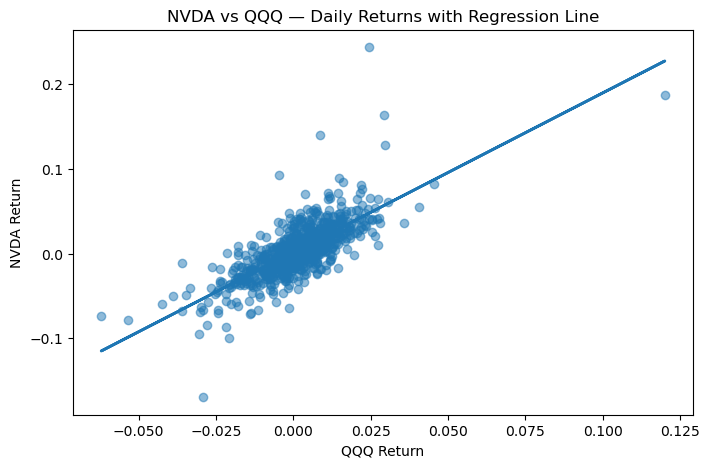

In [20]:
scatter_plot(TICKER[0])

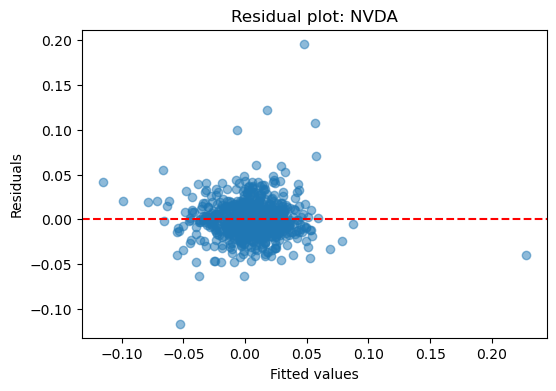

In [21]:
residual_plot(TICKER[0], model)

### AMD

In [22]:
model = regression(TICKER[1])


=== Regression: AMD Return ~ QQQ Return ===
                            OLS Regression Results                            
Dep. Variable:             AMD_Return   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.478
Method:                 Least Squares   F-statistic:                     687.6
Date:                Sun, 16 Nov 2025   Prob (F-statistic):          4.59e-108
Time:                        15:03:23   Log-Likelihood:                 1749.0
No. Observations:                 752   AIC:                            -3494.
Df Residuals:                     750   BIC:                            -3485.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const  

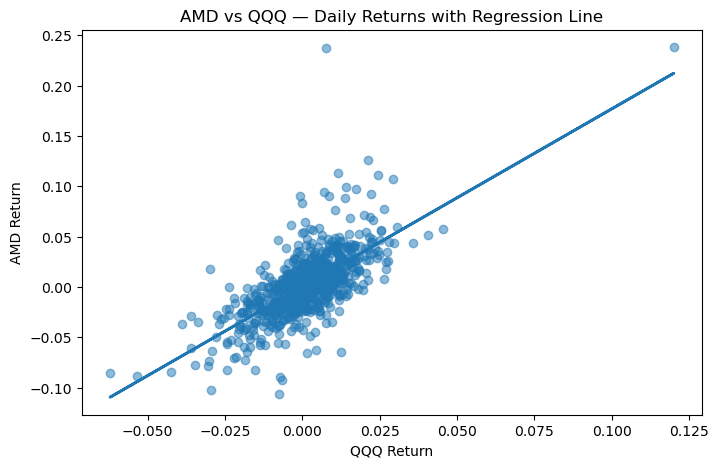

In [23]:
scatter_plot(TICKER[1])

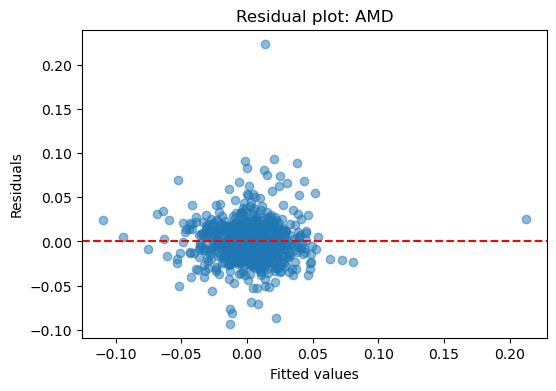

In [24]:
residual_plot(TICKER[1], model)

### INTC

In [25]:
model = regression(TICKER[2])


=== Regression: INTC Return ~ QQQ Return ===
                            OLS Regression Results                            
Dep. Variable:            INTC_Return   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     243.7
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           8.81e-48
Time:                        15:03:57   Log-Likelihood:                 1616.9
No. Observations:                 752   AIC:                            -3230.
Df Residuals:                     750   BIC:                            -3221.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

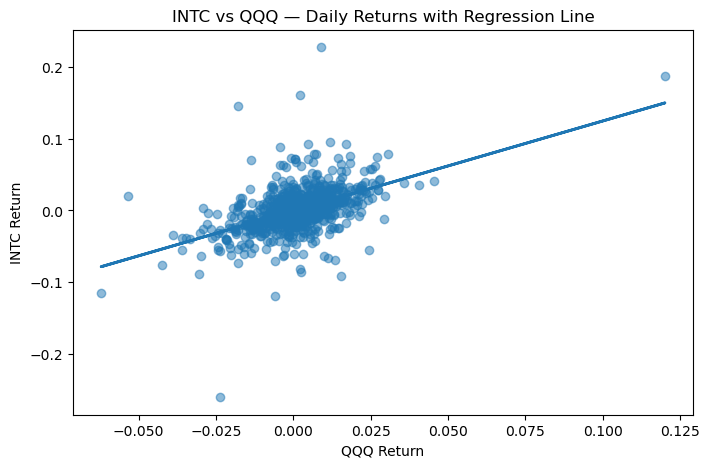

In [26]:
scatter_plot(TICKER[2])

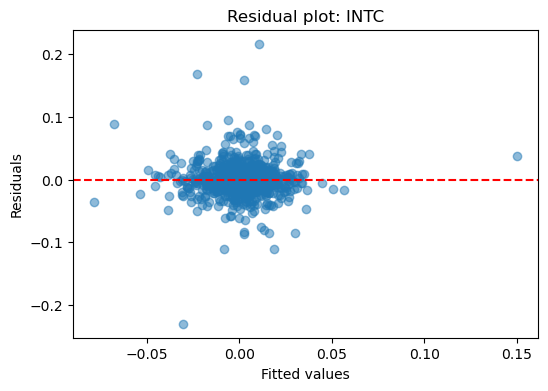

In [27]:
residual_plot(TICKER[2], model)